# 0 - Get corner points and px-cm (template)

Use this notebook to extract corner points and pixel/cm factors from CVAT annotations. Fill in paths and visualize results.

**Output location:**
This notebook saves to `saved_output/` (local directory). After running this notebook on your laptop, manually copy the saved_output directory to `{basedir}/saved_output/` on the remote machine where the main analysis will be run.

In [5]:
import os
WORKING_DIRECTORY = "/home/beesbook/jacob/bb_local_sync/MAIN/"
os.chdir(WORKING_DIRECTORY)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import bb_metrics
cfg = bb_metrics.load_config('/path/to/your/season_config.py')  # replace with your config
from bb_metrics import calibration as cal

# set active config for downstream functions
bb_metrics.set_config(cfg)

from bb_metrics import datafunctions as dfunc


# Create timelapse comb videos for easy annotation

In [ ]:
# Create comb timelapse videos from daily background images
# This combines camera pairs into side-by-side videos showing comb changes over time

import os
import subprocess

# Get paths from config
comb_images_root = str(cfg.comb_images_root)
video_output_dir = os.path.join(comb_images_root, 'videos_per_hive')

# Path to the script in bb_metrics
script_path = os.path.join(os.path.dirname(bb_metrics.__file__), 'create_comb_timelapse_videos.sh')


# Build command
# Options:
#   --comb-images-dir: Root directory containing cam-X subdirectories with .png files
#   --outdir: Where to save the output videos
#   --full-res: (optional) Keep full resolution instead of scaling to 50%.  For annotating, downscaled by 50% (the script default) is better
cmd = [
    script_path,
    '--comb-images-dir', comb_images_root,
    '--outdir', video_output_dir
]

print(f"Creating comb timelapse videos...")
print(f"  Input dir: {comb_images_root}")
print(f"  Output dir: {video_output_dir}")

result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0:
    print(f"\n✓ Success! Videos created in: {video_output_dir}")
    print("\nScript output:")
    print(result.stdout)
else:
    print(f"\n✗ Error occurred:")
    print(result.stderr)


# Next:  do annotations in CVAT

Install CVAT (running locally is better, due to the large images) and run with docker, and create a job for each camera, which has one image per hive per day.

After installing, this is how to run: 
- Start docker
- Run commands:
```
cd cvat
​​docker compose up -d
```

Then:
- In Chrome, go to ```
localhost:8080```
- Login (first create a login id for local use)
- create a Task, and add the label types 'corner' (point) and 'frame' (rectangle)

See example below for annotation
- Annotate the corner point each day (use ‘track’ to make this easier).
    - Tip:  use the star-shaped 'switch keyframe property' to designate keyframes on the frame before a shift in position.  The default interpolation is linear, but for these we want step-wise, so designating a keyframe just before a shift will do this
- Annotate the inside of the frame in the last video frame (to use for pixel-cm conversion).  

When finished, go back to 'tasks' then:
- export as CVAT for video 1.1



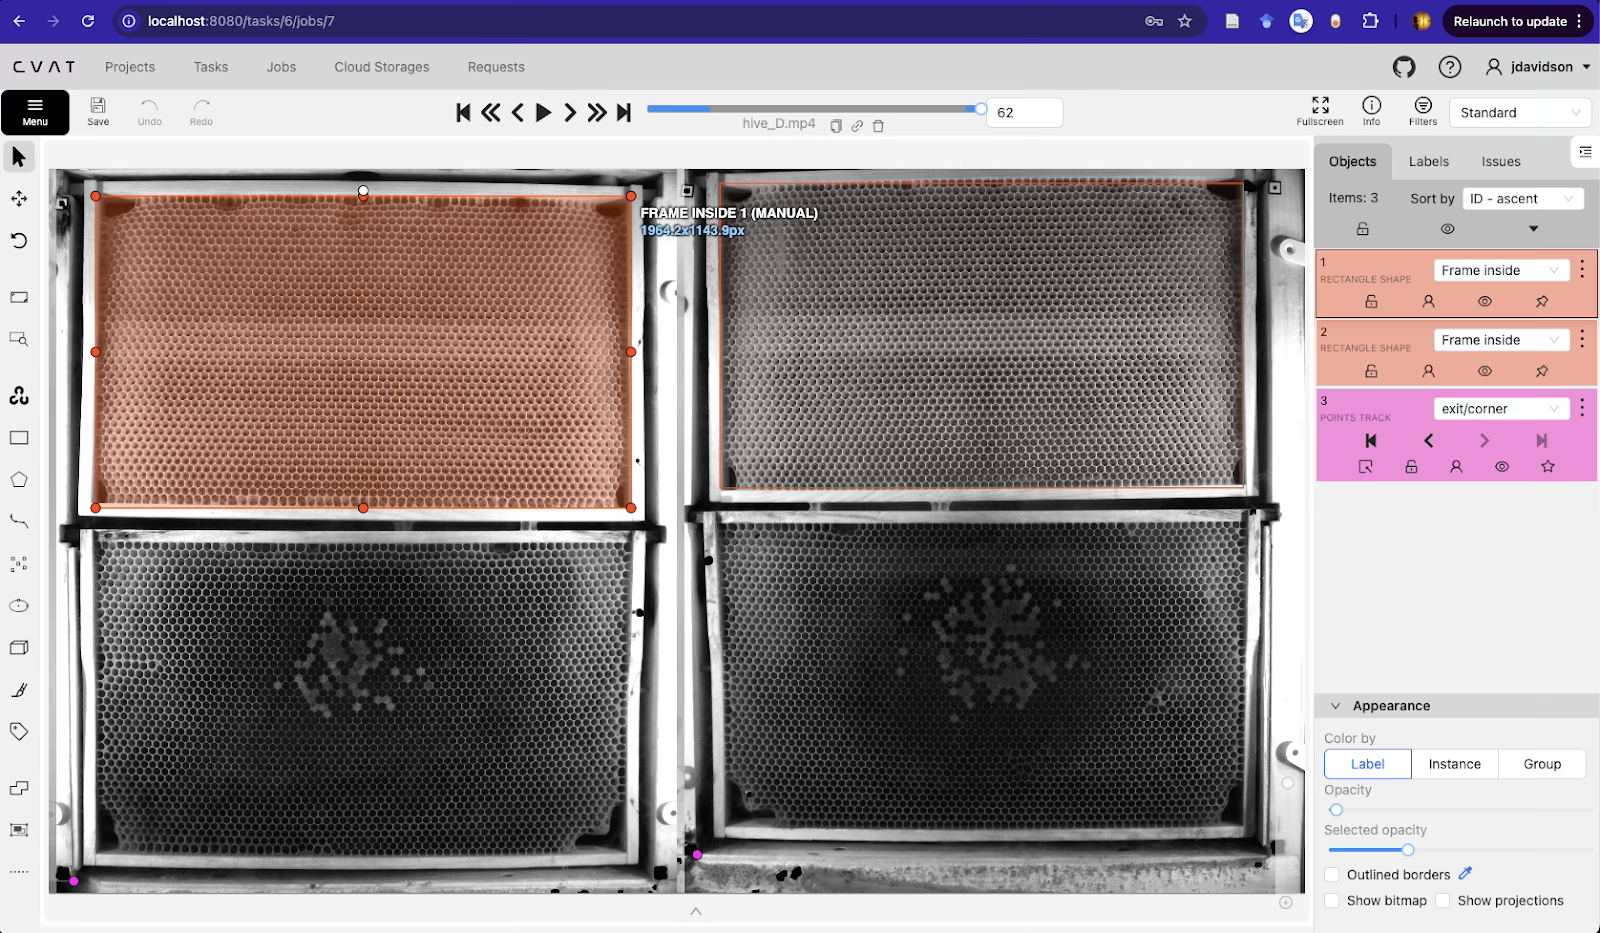

# Read in annotations to save df_cornerpoints and df_px_per_cm

In [7]:
# Paths from config (update in config file as needed)
images_root = cfg.comb_images_root
print(images_root)
xml_dir = cfg.calib_xml_dir
xmlfiles = sorted(xml_dir.glob('*.xml'))

xml_dfs = [cal.parse_annotation_xml(f) for f in xmlfiles]
cam_ts = cal.build_cam_timestamps(images_root)

corner_df = cal.corner_points_from_annotations(xml_dfs, xmlfiles, cam_ts)
df_px_per_cm = cal.pixels_per_cm_from_boxes(xml_dfs, xmlfiles)

display(corner_df.head())
display(df_px_per_cm.head())

outdir = Path('saved_output')
outdir.mkdir(exist_ok=True)
corner_df.to_csv(outdir / 'df_cornerpoints.csv', index=False)
df_px_per_cm.to_csv(outdir / 'df_px_per_cm.csv', index=False)


/mnt/trove/beesbook2025/comb_background


,hive,cam,timestamp,corner_x,corner_y,midday_utc
0,A,0,2025-06-17 07:29:25+00:00,242.08,73.88,2025-06-17 12:00:00+00:00
1,A,0,2025-06-18 17:29:38+00:00,242.08,73.88,2025-06-18 12:00:00+00:00
2,A,0,2025-06-19 18:59:23+00:00,242.08,73.88,2025-06-19 12:00:00+00:00
3,A,0,2025-06-20 20:00:01+00:00,242.08,73.88,2025-06-20 12:00:00+00:00
4,A,0,2025-06-23 02:58:49+00:00,400.20,79.20,2025-06-23 12:00:00+00:00


,hive,cam,pixels_per_cm
0,A,0,111.204000
1,A,1,110.640000
2,B,2,115.160000
3,B,3,110.458857
4,C,4,112.263429


## Visualize corner points to check offset_div_cm

Set your manual offsets (e.g., `offset_div_cm`, `frame_width_cm`) and overlay on sample images to verify.


In [ ]:
# Example visualization: overlay divisions on random images
import random
from glob import glob
from bb_binary.parsing import parse_image_fname

offset_div_cm = getattr(cfg, 'offset_div_cm', 0.0)
frame_width_cm = getattr(cfg, 'frame_width_cm', 0.0)
YPIXELS = getattr(cfg, 'ypixels', None)
XPIXELS = getattr(cfg, 'xpixels', None)

print('offset_div_cm=', offset_div_cm, 'frame_width_cm=', frame_width_cm)
assert YPIXELS is not None and XPIXELS is not None, "Set ypixels/xpixels in config"

# sample images
allimages = glob(str(images_root) + '/**/*.png', recursive=True)
image_filenames = random.choices(allimages, k=min(6, len(allimages)))
image_data = [plt.imread(i) for i in image_filenames]
image_camdt = [parse_image_fname(Path(f).name.split('background_',1)[-1]) for f in image_filenames]

In [ ]:

for img, (cam, dt), fname in zip(image_data, image_camdt, image_filenames):
    f, ax = plt.subplots(1, 1, figsize=(10, 15))
    ax.imshow(np.rot90(img, 3), cmap='gray')

    corner_x, corner_y, _ = dfunc.get_corner_point_for_date(cam, dt, corner_df)

    px_per_cm = df_px_per_cm.loc[df_px_per_cm['cam'] == cam, 'pixels_per_cm']
    if len(px_per_cm) == 0:
        continue
    px_per_cm = px_per_cm.values[0]

    # Corner points are in top-left origin (same as image display)
    ax.scatter(corner_x, corner_y, c='red')
    ax.scatter(corner_x + frame_width_cm * px_per_cm, corner_y, c='orange')
    ax.axhline(corner_y + offset_div_cm * px_per_cm, color='cyan')
    ax.set_title(Path(fname).name)
    plt.show()